Using device: cpu

Training for sequence length: 10

Training for sequence length: 50

Training for sequence length: 100

Final Results:
   seq_length      loss   time_sec   memory_MB
0          10  0.056018   3.766612  434.457031
1          50  0.078991  12.228548  468.648438
2         100  0.076227  24.565012  469.351562


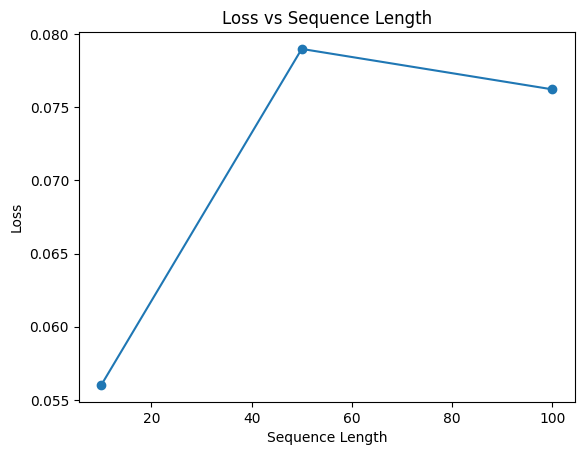

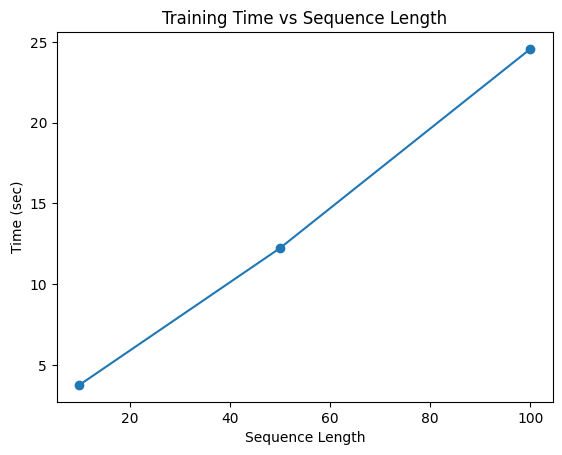

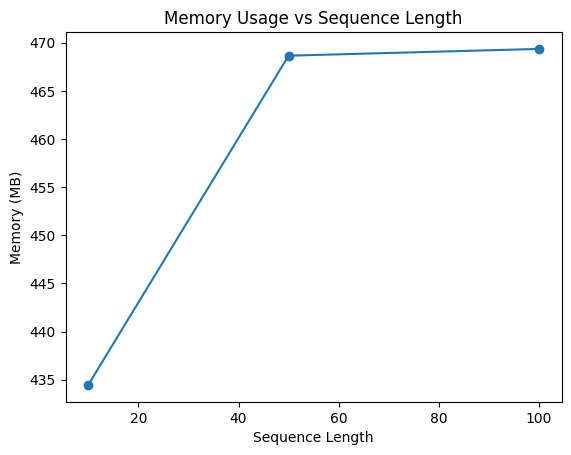


Saved as results.csv ✅


In [1]:
# ==============================
# 1. INSTALL & IMPORTS
# ==============================
!pip install torch torchvision matplotlib pandas psutil

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
import gc

from torch.utils.data import DataLoader, TensorDataset

# ==============================
# 2. DEVICE (GPU if available)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==============================
# 3. DATASET (REDUCED SIZE)
# ==============================
text = "this is a simple dataset for lstm context window experiment " * 50

chars = sorted(list(set(text)))
char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

encoded = np.array([char2idx[c] for c in text])
vocab_size = len(chars)

# ==============================
# 4. SEQUENCE CREATION
# ==============================
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# ==============================
# 5. LSTM MODEL
# ==============================
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# ==============================
# 6. TRAIN FUNCTION (BATCHED)
# ==============================
def train_model(seq_length, epochs=3, batch_size=64):
    X, y = create_sequences(encoded, seq_length)

    X = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = LSTMModel(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    end_time = time.time()

    memory = psutil.Process().memory_info().rss / (1024**2)

    return loss.item(), end_time - start_time, memory

# ==============================
# 7. RUN EXPERIMENTS
# ==============================
configs = [10, 50, 100]   # safe configs

results = []

for seq_len in configs:
    print(f"\nTraining for sequence length: {seq_len}")

    loss, train_time, memory = train_model(seq_len)

    results.append({
        "seq_length": seq_len,
        "loss": loss,
        "time_sec": train_time,
        "memory_MB": memory
    })

    # FREE MEMORY AFTER EACH RUN
    gc.collect()
    torch.cuda.empty_cache()

# ==============================
# 8. RESULTS TABLE
# ==============================
df = pd.DataFrame(results)
print("\nFinal Results:")
print(df)

# ==============================
# 9. VISUALIZATION
# ==============================
plt.figure()
plt.plot(df["seq_length"], df["loss"], marker='o')
plt.title("Loss vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(df["seq_length"], df["time_sec"], marker='o')
plt.title("Training Time vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Time (sec)")
plt.show()

plt.figure()
plt.plot(df["seq_length"], df["memory_MB"], marker='o')
plt.title("Memory Usage vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Memory (MB)")
plt.show()

# ==============================
# 10. SAVE RESULTS
# ==============================
df.to_csv("results.csv", index=False)

print("\nSaved as results.csv ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>